In [22]:
import numpy as np
import matplotlib.pyplot as plt

from phase import PhaseSolver, PhaseConfig

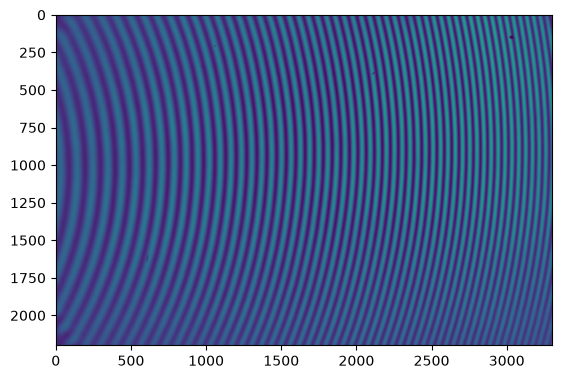

In [23]:
# Read data
data = np.load("../../data/both_arms_piezo_no_delay_20260902_142933.npz")
stack = data["stack"][0]

plt.imshow(stack[0])

In [8]:
# Get noise
data_noise = np.load("../../data/sample_arm_20260902_142549.npz")
stack_noise = data_noise['stack'][0]

In [16]:
def gauss1d(sig, truncate=4.0):
    r = int(truncate*sig + 0.5)
    x = np.arange(-r, r+1)
    k = np.exp(-x**2/(2*sig**2))
    return k / k.sum()

def blur2d_fft(img, sig):
    k = gauss1d(sig)
    H, W = img.shape
    kx = np.zeros(W); kx[:len(k)] = k; kx = np.roll(kx, -(len(k)//2))
    ky = np.zeros(H); ky[:len(k)] = k; ky = np.roll(ky, -(len(k)//2))
    F = np.fft.fft2(img)
    F *= np.fft.fft(ky)[:, None]
    F *= np.fft.fft(kx)[None, :]
    return np.fft.ifft2(F).real

sig = 10
stack_smooth = np.empty_like(stack_noise, dtype=float)
for n in range(stack_noise.shape[0]):
    stack_smooth[n] = blur2d_fft(stack_noise[n], sig)

In [19]:
print(np.std(stack_smooth-stack_noise, axis=(1,2)))

[20.29206637 20.20531734 20.24814864 20.19254274 20.24666924 20.25215105
 20.39323771 20.27908517 20.23489425 20.27976339 20.23421677 20.21595755
 20.30517142 20.32315057 20.25997343 20.29034049 20.29924147 20.22566046
 20.32200148 20.26264842 20.28486642 20.26783001 20.29868452 20.2373321
 20.2717127  20.27623197 20.32827466 20.28675904 20.1305017  20.27809381
 20.21913776 20.26222303 20.24462453 20.20782649 20.26747423 20.30516118
 20.26389867 20.22669616 20.18779594 20.20942615 20.24385025 20.29062939
 20.2723663  20.23375315 20.19724598 20.22420296 20.28479117 20.2296011
 20.24944472 20.28137967 20.28521779 20.21366389 20.21944238 20.24908457
 20.25516556 20.23252709 20.25253118 20.28609649 20.18051704 20.27217573]


In [20]:
In = stack.reshape(stack.shape[0], -1).astype(float)   # (60, 2200*3300)
print(In.std())          # overall spread of all intensity values, camera units

338.8671515674153


In [62]:
N = 10
stack_probe = stack[:N]

#aia params
tol = 1e-4
iters = 40

# tilt params
refine_tol = 1e-6
refine_iters = 0

cfg = PhaseConfig.from_yaml("phase_config.yaml")
cfg.method_kwargs['iters'] = iters
cfg.method_kwargs['tol'] = tol
cfg.method_kwargs['refine_iters'] = refine_iters
cfg.method_kwargs['refine_tol'] = refine_tol

solver = PhaseSolver(cfg)
solver.fit(stack_probe)
solver.result_.print_summary()

converged:     True
kappa_p:       2.92854
kappa_ps:      2.02843
predicted_rms: 0.0468563
degree:           1
refine_converged: False
refine_iters_run: 0
best_iter:        -1
rms_frac:         nan
kappa_fit:        nan
coeffs_rms:       [0. 0.]
reconstruction_error: 43.2183


In [63]:
sigma_n = np.sqrt(stack_probe*0.83) / 0.83    # (N,P), gain=100
sigma_pixel = np.sqrt((sigma_n**2).mean(0))          # (P,)

print(f"RMS noise: {np.sqrt((sigma_pixel**2).mean())}")
print(f"Noise floor: {np.sqrt((sigma_pixel**2).mean()) / stack_probe.std()}")

RMS noise: 28.189104080200195
Noise floor: 0.0818786472082138


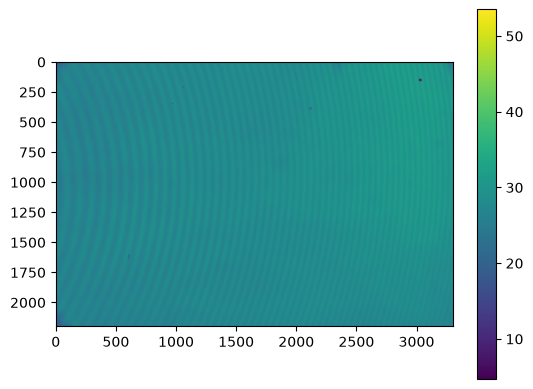

In [57]:
plt.imshow(sigma_pixel)
plt.colorbar()

In [4]:
a_aia = solver.a_
b_aia = solver.b_

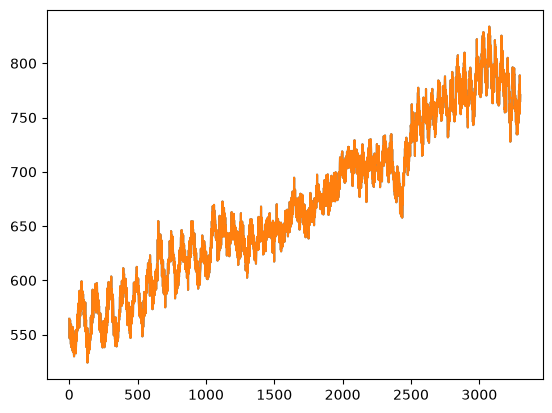

In [5]:
plt.plot(a_aia[1000])
plt.plot(solver.a_[1000])

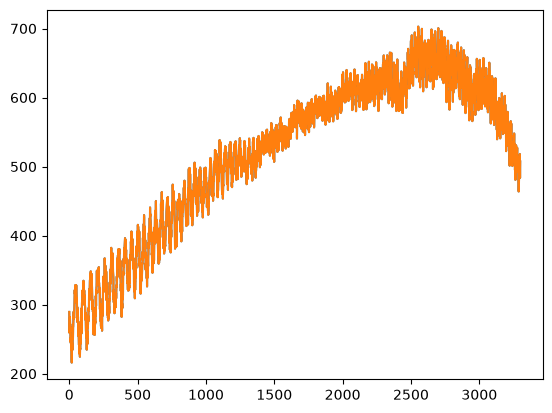

In [6]:
plt.plot(b_aia[1000])
plt.plot(solver.b_[1000])

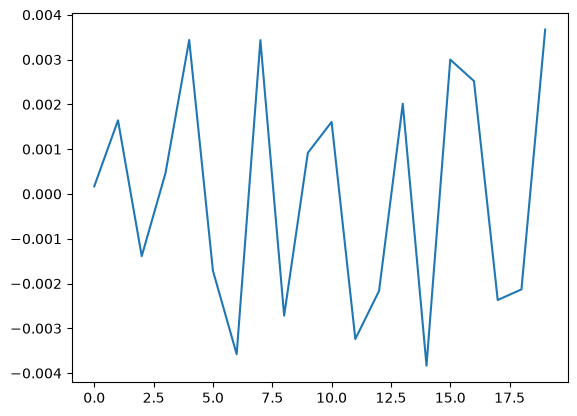

In [7]:
a = a_aia
b = b_aia
phi = solver.phi_
delta = solver.delta_

u = b * np.cos(phi)
v = -b * np.sin(phi)

proj = np.zeros(N)
for n in range(N):
    dn = delta[n]
    resid = stack_probe[n] - (a + u*np.cos(dn) + v*np.sin(dn))
    bsin = u*np.sin(dn) - v*np.cos(dn)          # sin(φ+δ_n) pattern
    proj[n] = (resid * bsin).sum() / (bsin*bsin).sum()

plt.plot(proj)

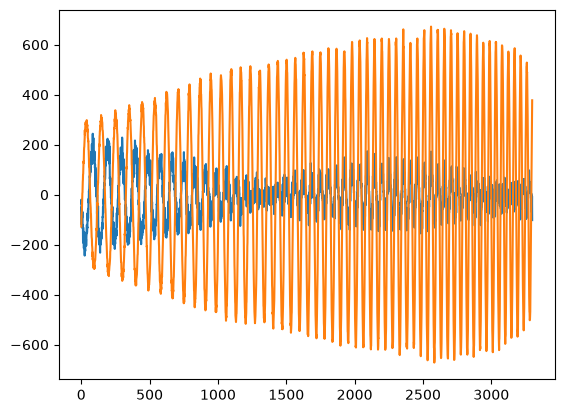

In [8]:
plt.plot(resid[1000])
plt.plot(bsin[1000])

## Is the residual a step-field error, or something else?

`docs/step_field_residuals.md` §5.6 predicts that *any* finite-degree spatially-varying
phase-step error produces a residual whose amplitude is a smooth, low-order polynomial in
`(x, y)` -- so it can only vary slowly across the field, and (for the pure-tilt term
specifically) should be smallest near the field centroid and grow outward. A residual that is
instead uniform in amplitude regardless of position, but strongly correlated with the recovered
phase value itself, is a phase-locked ripple `eps(phi)` (an imperfect frame model -- see
`phase/ripple.py`) -- no amount of `aia_tilt`/higher-order step-field fitting can remove that.

**Decision rule:**
- RMS grows with distance from the centroid below → step-field error; higher-order terms
  (quadratic, ...) are worth pursuing.
- RMS ~flat with radius but the ripple cell below shows a large, well-fit `eps(phi)` → fringe
  harmonic distortion, not a step-field error; use `phase/ripple.py` instead and stop here.


Text(0.5, 1.0, 'Residual RMS vs. radius -- growing outward is the step-field signature')

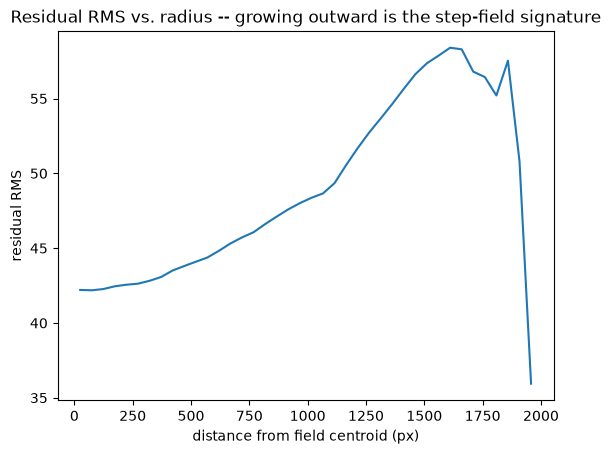

In [9]:
# Residual RMS vs. distance from the field centroid.
H, W = a.shape
g = solver.g_

model = a[None] + g[:, None, None] * (u[None] * np.cos(delta)[:, None, None]
                                       + v[None] * np.sin(delta)[:, None, None])
resid_full = stack_probe - model                          # (N, H, W)
rms_map = np.sqrt(np.mean(resid_full ** 2, axis=0))        # (H, W)

# Same field-centroid origin convention as phase.methods.step_field._poly_basis.
yy, xx = np.meshgrid(np.arange(H, dtype=float), np.arange(W, dtype=float), indexing="ij")
r = np.sqrt((xx - xx.mean()) ** 2 + (yy - yy.mean()) ** 2)

nbins = 40
edges = np.linspace(0, r.max(), nbins + 1)
bin_idx = np.clip(np.digitize(r.ravel(), edges) - 1, 0, nbins - 1)
counts = np.bincount(bin_idx, minlength=nbins)
bin_rms = np.bincount(bin_idx, weights=rms_map.ravel(), minlength=nbins) / np.maximum(counts, 1)
bin_centers = 0.5 * (edges[:-1] + edges[1:])

plt.plot(bin_centers, bin_rms)
plt.xlabel("distance from field centroid (px)")
plt.ylabel("residual RMS")
plt.title("Residual RMS vs. radius -- growing outward is the step-field signature")

rms_before: 0.7633 rad
rms_after:  0.7593 rad


Text(0.5, 1.0, 'Phase-locked ripple eps(phi) -- large & well-fit here argues against a step-field cause')

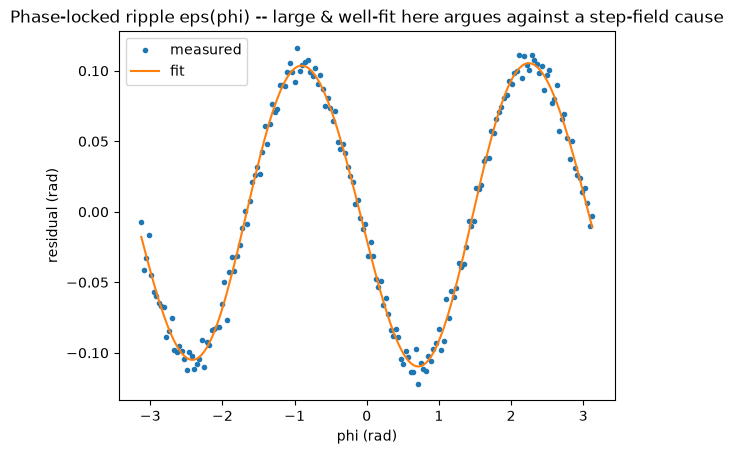

In [10]:
# Phase-locked-ripple cross-check (phase/ripple.py). estimate_phase_ripple wants a mask of
# phase known to be smooth/flat (e.g. bare substrate around a sample) -- no such ROI is known
# here, so this defaults to "well-modulated, away from the border" purely so the cell runs.
# Replace `mask` with a real known-flat ROI for a meaningful rms_before/rms_after.
from phase.ripple import estimate_phase_ripple, _eval_ripple

crop = 50
mask = np.zeros((H, W), dtype=bool)
mask[crop:-crop, crop:-crop] = True
mask &= b > np.percentile(b, 50)

ripple = estimate_phase_ripple(phi, mask=mask, weight=b)
print(f"rms_before: {ripple.rms_before:.4g} rad")
print(f"rms_after:  {ripple.rms_after:.4g} rad")

plt.plot(ripple.bin_centers, ripple.lut, ".", label="measured")
plt.plot(ripple.bin_centers, _eval_ripple(ripple.bin_centers, ripple.coeffs, ripple.orders),
         label="fit")
plt.xlabel("phi (rad)")
plt.ylabel("residual (rad)")
plt.legend()
plt.title("Phase-locked ripple eps(phi) -- large & well-fit here argues against a step-field cause")

## Arbitrary-degree step-field fit (`aia_step_field`)

Compare `degree = 1, 2, 3` on the same acquisition: `reconstruction_error` should keep
dropping, `kappa_fit` should stay low (a blown-up value means `degree` has outrun what this
fringe pattern can resolve), `rms_frac_history` should decrease monotonically each round, and
the recovered coefficient sequences should be **smooth in `n`** (a physical actuator drift) --
noisy frame-to-frame jumps would mean the fit is absorbing model error instead of real step
error.


In [46]:
N = 15
stack_probe = stack[30:45]

results = {}
for degree in (0, 1, 2):
    cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
    cfg_d.use_alpha = True
    cfg_d.method_kwargs.update(iters=iters, tol=tol, degree=degree,
                                refine_iters=20, refine_tol=1e-4)
    solver_d = PhaseSolver(cfg_d)
    solver_d.fit(stack_probe)
    results[degree] = solver_d
    mp = solver_d.method_param_
    print(f"degree={degree} converged={mp.refine_converged}  reconstruction_error={solver_d.reconstruction_error_:.4f}  "
          f"kappa_fit={mp.kappa_fit:.3g}  refine_iters_run={mp.refine_iters_run}  "
          f"rms_frac_history={[f'{x:.5f}' for x in mp.rms_frac_history]}")

degree=0 converged=False  reconstruction_error=57.0306  kappa_fit=nan  refine_iters_run=0  rms_frac_history=[]
degree=1 converged=True  reconstruction_error=36.0367  kappa_fit=1.47  refine_iters_run=6  rms_frac_history=['0.11297', '0.10532', '0.10231', '0.10183', '0.10166', '0.10157']
degree=2 converged=True  reconstruction_error=27.5960  kappa_fit=3.27  refine_iters_run=7  rms_frac_history=['0.09627', '0.08445', '0.08074', '0.07989', '0.07960', '0.07945', '0.07936']


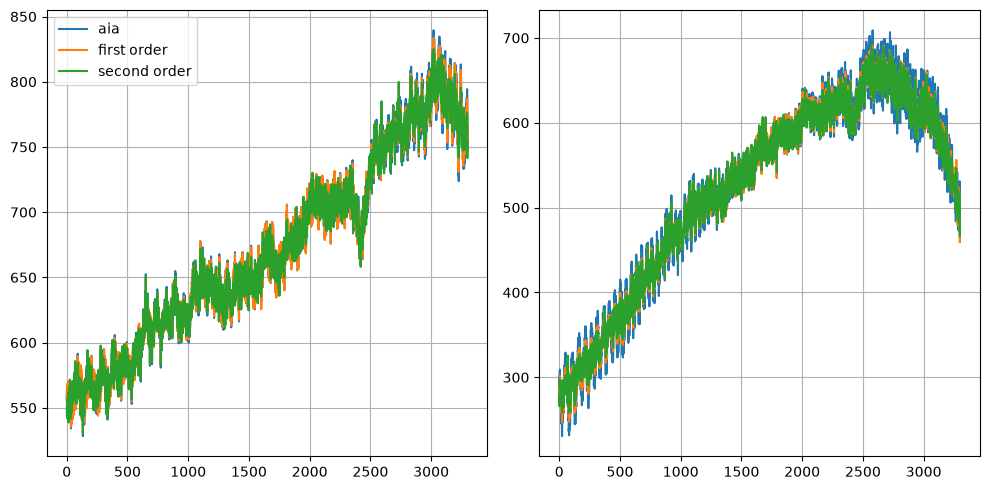

In [35]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(results[0].result_.a[1000], label="aia")
plt.plot(results[1].result_.a[1000], label="first order")
plt.plot(results[2].result_.a[1000], label="second order")
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(results[0].result_.b[1000])
plt.plot(results[1].result_.b[1000])
plt.plot(results[2].result_.b[1000])
plt.grid()

plt.tight_layout()

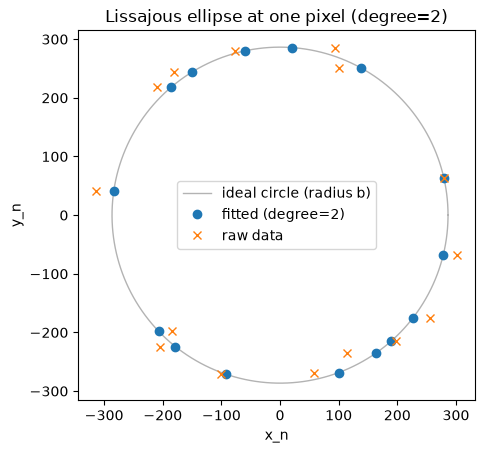

In [50]:
from phase.methods.step_field import _poly_basis

degree = 2                                        # pick which results[...] fit to inspect
r = results[degree].result_
mp = results[degree].method_param_
a_, b_, phi_ = r.a, r.b, r.phi
u_ = b_ * np.cos(phi_)
v_ = -b_ * np.sin(phi_)

i = a_.size // 2                                  # a pixel index (flat)
row, col = np.unravel_index(i, a_.shape)
u_i, v_i = u_[row, col], v_[row, col]
b_i = np.hypot(u_i, v_i)

# The degree-2 model's actual per-frame step AT THIS PIXEL, not the plain
# piston delta -- delta_n(x,y) = delta_n + coeffs[:,n] @ basis(x,y)
# (docs/step_field_residuals.md Eq. T1), evaluated at (row, col) only (no
# need to build the full (N,H,W) field for one pixel).
basis = _poly_basis(*a_.shape, degree, np)        # (J, P)
basis_i = basis[:, i]                             # (J,) -- this pixel's basis values
delta_eff = r.delta + mp.coeffs.T @ basis_i        # (N,) -- this pixel's true step

xn = u_i * np.cos(delta_eff) + v_i * np.sin(delta_eff)   # fitted x_n, degree-2 model
yn = u_i * np.sin(delta_eff) - v_i * np.cos(delta_eff)   # quadrature

# Raw experimental x_n at the same pixel, alpha/g-corrected the same way the
# model is (I_n = alpha_n*(a + g_n*(u*cos(delta_n)+v*sin(delta_n)))) -- paired
# with the *model's* yn, since a single-channel intensity sample only gives
# one real number per frame, not an independent (x,y) pair. Points straying
# off the fitted circle are frames where the raw data disagrees with what
# the degree-2 fit predicts -- this is the actual "how good is my model"
# check, now that the reference uses the fitted step field, not the piston.
xn_raw = (stack_probe[:, row, col] / r.alpha - a_[row, col]) / r.g

theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(b_i * np.cos(theta), b_i * np.sin(theta), '-', color='0.7', lw=1,
         label='ideal circle (radius b)')
plt.plot(xn, yn, 'o', label=f'fitted (degree={degree})')
plt.plot(xn_raw, yn, 'x', label='raw data')
plt.gca().set_aspect('equal')
plt.xlabel('x_n')
plt.ylabel('y_n')
plt.title(f'Lissajous ellipse at one pixel (degree={degree})')
plt.legend()

In [51]:
from phase.backend import wrap

xr, yr = xn_raw, yn          # yr still comes from the model -- see the note in the cell above
th = np.arctan2(yr, xr)
rad = np.hypot(xr, yr)

print("radial scatter (amp err):", np.std(rad) / b_i)                # alpha/g miscalibration, noise
print("angular scatter (delta err):", np.std(wrap(th - delta_eff)))  # phase-step (delta_n) error

radial scatter (amp err): 0.05577551580736205
angular scatter (delta err): 0.09831411619599864
